# Quantum Image Fake/Real Detection

**Companion notebook to the QHBERT (text) pipeline in this project** — this one targets the **image**
modality: given a photo, predict whether it is a **real photograph** or an **AI-generated ("fake")
image**. That's the image-forensics signal a full multimodal fake-news system would consume; it does
not read article text or context (see the honest-limitations section at the end).

**Data sources**
- Fake images: [`InfImagine/FakeImageDataset`](https://huggingface.co/datasets/InfImagine/FakeImageDataset)
  — 100% AI-generated images (IF/DeepFloyd, Stable Diffusion v1.5, StyleGAN3 for training; + CogView2,
  SD v2.1, Midjourney v5 for validation). **There is no "real" class in this repo** — verified directly
  against its `MetaData/*.csv` label files (every row is label `0` = fake).
- Real images: [`pixparse/cc3m-wds`](https://huggingface.co/datasets/pixparse/cc3m-wds) — a webdataset
  mirror of Conceptual Captions (CC3M) with actual decoded photo bytes and an official `train`/`validation` split.
- Quantum technique: [`Quant02/Quatum-Image-Processing`](https://github.com/Quant02/Quatum-Image-Processing)
  (Qiskit) — its **QPIE** (Quantum Probability Image Encoding: normalize pixel intensities, amplitude-encode)
  is the encoding scheme used by our quantum circuit below; its **QHED** (Quantum Hadamard Edge Detection)
  is run verbatim, as a small demo, in Section 10.

**Architecture** mirrors this project's existing QHBERT text pipeline exactly: a frozen pretrained encoder
→ a trainable "bridge" MLP → a variational quantum circuit → a classical head. Here the frozen encoder is
an ImageNet CNN instead of DistilBERT, and the quantum encoding is amplitude embedding (QPIE) instead of
angle embedding.

> **⚠️ Scale reality check — read before running a full "use all data" pass.** The full combined corpus
> (all 3 fake training generators + all 6 fake validation generators + a matched real slice of CC3M) is on
> the order of **~1TB of network transfer**. This notebook streams and decodes on the fly — it never
> bulk-downloads or persists the full corpus to disk — but you should still expect a full run to take many
> hours and likely **span multiple Kaggle/Colab sessions**. Checkpointing (Section 7) is not optional here.
> Before launching a full run, set `N_TRAIN_PER_CLASS`/`N_VAL_PER_CLASS` in the config below to a small
> number (e.g. `50`) and run the whole notebook once as a smoke test.


## 1. Setup

**Kaggle note:** internet access is **off by default** on Kaggle notebooks — every cell below that
installs packages or streams from Hugging Face needs it. Enable it via the notebook's side panel:
**Settings → Internet → On** (this also requires a verified phone number on your Kaggle account).
Colab has internet on by default, so this only matters if you're running on Kaggle.

We do **not** `git clone` the `Quatum-Image-Processing` repo here. Section 10's QHED code below is a
full, standalone port of that repo's actual algorithm (I read its source directly while designing this
notebook and rewrote it to run on current Qiskit — see Section 10 for why), so there's nothing left for
the notebook itself to import or execute from a live clone of it.


In [31]:
# Kaggle/Colab base images already have most of torch/numpy; -q keeps this quiet.
# Note: only `qiskit` (core) is needed, not qiskit-aer — Section 10 uses Statevector()
# for ideal simulation, which doesn't require a separate backend/simulator package.
!pip install -q torch torchvision pennylane qiskit \
    datasets huggingface_hub scikit-learn pandas numpy matplotlib seaborn tqdm pillow requests


^C
ERROR: Operation cancelled by user


In [32]:
import os
import io
import re
import json
import math
import random
import itertools

import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from PIL import Image
from tqdm.auto import tqdm

import pennylane as qml
from datasets import load_dataset
from huggingface_hub import HfApi, hf_hub_url

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))


Using device: cuda
Tesla T4


## 2. Configuration

Everything tunable lives in one dict, following this project's existing convention (see `qiskit.ipynb`).
`N_TRAIN_PER_CLASS` / `N_VAL_PER_CLASS` are capped at `10_000` each by default — a Kaggle-session-sized
run instead of the full ~2M fake + ~2.9M real images "use all data" implies. Set them to a small int
(e.g. `50`) for an even faster smoke-test pass, or to `None` to stream everything available (expect
**~1TB of transfer and tens of hours** if you do that — see the scale warning at the top of this notebook).


In [33]:
def setup_checkpoint_dir():
    """Kaggle/Colab sessions are time-limited, so a full "use all data" run needs
    checkpoints on storage that survives a session reset, not local scratch disk."""
    if os.path.isdir("/kaggle/working"):
        d = "/kaggle/working/checkpoints"
        print("Detected Kaggle. Note: /kaggle/working only persists if you 'Save Version' — "
              "for true cross-session resumability, also save this folder as a Kaggle Dataset.")
    else:
        try:
            from google.colab import drive
            drive.mount("/content/drive", force_remount=False)
            d = "/content/drive/MyDrive/quantum_image_checkpoints"
            print("Detected Colab. Checkpointing to Google Drive so it survives session resets.")
        except ImportError:
            d = "./checkpoints"
            print("Neither Kaggle nor Colab detected — checkpointing to a local ./checkpoints folder.")
    os.makedirs(d, exist_ok=True)
    return d


CHECKPOINT_DIR = setup_checkpoint_dir()


Detected Kaggle. Note: /kaggle/working only persists if you 'Save Version' — for true cross-session resumability, also save this folder as a Kaggle Dataset.


In [34]:
CONFIG = {
    # --- quantum circuit ---
    "n_qubits": 6,          # 2**6 = 64 amplitudes -> matches the repo's native 8x8-patch QPIE granularity
    "n_layers": 3,          # same depth as the QHBERT text ansatz

    # --- classical encoder / bridge ---
    "cnn_backbone": "resnet18",
    "cnn_embed_dim": 512,
    "bridge_hidden": 128,
    "image_size": 224,      # CNN input resolution
    "dropout": 0.3,

    # --- training ---
    "batch_size": 16,
    # NOTE: each epoch re-streams every image from scratch (no local caching) -- at full
    # "use all data" scale this multiplies total network transfer by `epochs`. Consider
    # epochs=1 for a genuine full-corpus run unless bandwidth/time allow more.
    "epochs": 3,
    "lr_classical": 1e-3,
    "lr_quantum": 1e-2,

    # --- data scale: None = use everything available; capped here to keep runs
    # Kaggle-session-sized instead of the ~1TB/~5M-image full pull ---
    "N_TRAIN_PER_CLASS": 10_000,
    "N_VAL_PER_CLASS": 10_000,

    # --- checkpointing ---
    "checkpoint_dir": CHECKPOINT_DIR,
    "checkpoint_every_n_steps": 200,

    "seed": SEED,
}

CONFIG["patch_dim"] = 2 ** CONFIG["n_qubits"]  # amplitude-embedding vector length
print(json.dumps(CONFIG, indent=2, default=str))


{
  "n_qubits": 6,
  "n_layers": 3,
  "cnn_backbone": "resnet18",
  "cnn_embed_dim": 512,
  "bridge_hidden": 128,
  "image_size": 224,
  "dropout": 0.3,
  "batch_size": 16,
  "epochs": 3,
  "lr_classical": 0.001,
  "lr_quantum": 0.01,
  "N_TRAIN_PER_CLASS": 10000,
  "N_VAL_PER_CLASS": 10000,
  "checkpoint_dir": "/kaggle/working/checkpoints",
  "checkpoint_every_n_steps": 200,
  "seed": 42,
  "patch_dim": 64
}


## 3. Data ingestion

### Why not just `load_dataset(...)` directly on the fake-image files?

Each subset of `InfImagine/FakeImageDataset` is stored as multiple `*.tar.gz.NN` files — but these are
**not independent webdataset shards**. They're raw byte-chunks of one continuous gzip stream, split with
something like the Unix `split` command (the dataset's own README confirms this: it tells you to
`cat X.tar.gz.* > X.tar.gz && tar -xvf X.tar.gz` before you can extract anything). If you point a generic
webdataset loader at these files directly, it reads the beginning of `.tar.gz.00` successfully (that's
exactly what the HF dataset-viewer preview — the `__key__`/`__url__`/`png` row you may have seen browsing
the dataset — is doing) and then fails once it hits the truncation point. **This is reproducible right now
against HF's own datasets-server**, which raises `tarfile.ReadError: unexpected end of data` if you try to
auto-convert this dataset.

So below we implement a small streaming reader that concatenates all of a subset's parts **in the correct
order** into one continuous byte stream and feeds that into Python's `tarfile` — decoding images
incrementally, without ever writing the multi-hundred-GB concatenated archive to disk.

### Real images

`pixparse/cc3m-wds` has no such problem — it's a proper webdataset repo with a real `train` (2.9M samples)
and `validation` (13.4K samples) split, columns `__key__`/`__url__`/`jpg`/`txt`. We use
`datasets.load_dataset(..., streaming=True)` directly.


In [35]:
import time
import tarfile


_RETRYABLE_ERRORS = (
    requests.exceptions.ChunkedEncodingError,
    requests.exceptions.ConnectionError,
    requests.exceptions.Timeout,
    requests.exceptions.RequestException,
)


class ChainedRemoteStream(io.RawIOBase):
    """Concatenates a sequence of remote HTTP resources into one forward-only byte stream.

    Needed because InfImagine/FakeImageDataset's `*.tar.gz.NN` files are raw byte-chunks of a
    single gzip stream, not independent archives — see the markdown above.

    These are multi-gigabyte downloads, so a transient connection drop mid-part is expected,
    not exceptional (e.g. `ChunkedEncodingError: IncompleteRead(...)`). On such an error this
    retries with an HTTP Range request that resumes from the exact byte offset already
    consumed for the current part, instead of restarting that multi-GB part from byte 0.
    """

    def __init__(self, urls, chunk_size=1 << 20, session=None, max_retries=8):
        self._urls = list(urls)
        self._chunk_size = chunk_size
        self._session = session or requests.Session()
        self._max_retries = max_retries
        self._url_idx = -1
        self._iter = None
        self._buf = b""
        self._buf_pos = 0
        self._bytes_from_current_url = 0
        self._advance_url()

    def _open_url(self, url, resume_from=0):
        headers = {"Range": f"bytes={resume_from}-"} if resume_from else {}
        resp = self._session.get(url, stream=True, headers=headers)
        resp.raise_for_status()
        return resp.iter_content(chunk_size=self._chunk_size)

    def _advance_url(self):
        self._url_idx += 1
        if self._url_idx >= len(self._urls):
            self._iter = None
            return False
        self._bytes_from_current_url = 0
        self._iter = self._open_url(self._urls[self._url_idx])
        return True

    def _next_chunk(self):
        """next(self._iter), transparently retrying (with a Range-resume) on network errors.
        Raises StopIteration once the current part is genuinely exhausted."""
        retry_count = 0
        while True:
            try:
                return next(self._iter)
            except StopIteration:
                raise
            except _RETRYABLE_ERRORS as e:
                retry_count += 1
                if retry_count > self._max_retries:
                    raise
                wait = min(2 ** retry_count, 30)
                print(f"[ChainedRemoteStream] part {self._url_idx}: transient "
                      f"{e.__class__.__name__} after {self._bytes_from_current_url} bytes -- "
                      f"retry {retry_count}/{self._max_retries} in {wait}s (resuming, not restarting)")
                time.sleep(wait)
                try:
                    self._iter = self._open_url(self._urls[self._url_idx],
                                                 resume_from=self._bytes_from_current_url)
                except _RETRYABLE_ERRORS:
                    continue  # reopening itself failed transiently too; loop and retry again

    def readable(self):
        return True

    def readinto(self, b):
        if len(b) == 0:
            return 0
        while self._buf_pos >= len(self._buf):
            if self._iter is None:
                return 0  # all parts exhausted
            try:
                self._buf = self._next_chunk()
                self._buf_pos = 0
                self._bytes_from_current_url += len(self._buf)
            except StopIteration:
                if not self._advance_url():
                    return 0
        n = min(len(b), len(self._buf) - self._buf_pos)
        b[:n] = self._buf[self._buf_pos:self._buf_pos + n]
        self._buf_pos += n
        return n


def discover_part_urls(repo_id, subfolder, repo_type="dataset"):
    """List and order a subset's archive part(s), and resolve them to direct URLs.

    Handles both layouts actually present in this dataset: multiple numbered `*.tar.gz.N`
    parts for larger subsets, and a single plain `*.tar.gz` file for subsets small enough
    that HF never split them (e.g. Midjourneyv5-5K, at 1.2GB, is one plain .tar.gz -- there's
    no `.tar.gz.0` for it, unlike every other subset here)."""
    api = HfApi()
    all_files = api.list_repo_files(repo_id, repo_type=repo_type)
    prefix = subfolder.rstrip("/") + "/"
    numbered = [f for f in all_files if f.startswith(prefix) and re.search(r"\.tar\.gz\.\d+$", f)]
    if numbered:
        numbered.sort(key=lambda f: int(re.search(r"\.(\d+)$", f).group(1)))
        parts = numbered
    else:
        parts = [f for f in all_files if f.startswith(prefix) and f.endswith(".tar.gz")]
    if not parts:
        raise FileNotFoundError(f"No .tar.gz part(s) found under {repo_id}/{subfolder}")
    return [hf_hub_url(repo_id, f, repo_type=repo_type) for f in parts]


def iter_split_gzip_tar(part_urls, member_suffix=".png"):
    """Yield (member_name, raw_bytes) for every matching file in a multi-part gzip'd tar,
    decoding incrementally as parts stream in (never materializes the full archive)."""
    stream = ChainedRemoteStream(part_urls)
    with tarfile.open(fileobj=stream, mode="r|gz") as tar:
        for member in tar:
            if not member.isfile():
                continue
            if member_suffix and not member.name.endswith(member_suffix):
                continue
            f = tar.extractfile(member)
            if f is None:
                continue
            yield member.name, f.read()


In [36]:
FAKE_REPO = "InfImagine/FakeImageDataset"

FAKE_SUBSETS = {
    "train": {
        "IF":         "ImageData/train/IFv1-CC1M/IFv1-dpmsolver++-50-1M",
        "SD15R":      "ImageData/train/SDv15R-CC1M/SDv15R-dpmsolver-25-1M",
        "StyleGAN3":  "ImageData/train/stylegan3-80K",
    },
    "val": {
        "IF":           "ImageData/val/IF-CC95K",
        "SD15":         "ImageData/val/SDv15-CC30K",
        "SD21":         "ImageData/val/SDv21-CC15K",
        "CogView2":     "ImageData/val/cogview2-22K",
        "StyleGAN3":    "ImageData/val/stylegan3-60K",
        "Midjourneyv5": "ImageData/val/Midjourneyv5-5K",
    },
}


def stream_fake_images(split, limit_per_generator=None):
    """Yields (PIL.Image, label=1, generator_name) across every generator in `split`
    ('train' or 'val'). `limit_per_generator=None` streams the entire generator."""
    for generator_name, subfolder in FAKE_SUBSETS[split].items():
        urls = discover_part_urls(FAKE_REPO, subfolder)
        count = 0
        for _name, data in iter_split_gzip_tar(urls, member_suffix=".png"):
            try:
                img = Image.open(io.BytesIO(data)).convert("RGB")
            except Exception:
                continue
            yield img, 1, generator_name
            count += 1
            if limit_per_generator is not None and count >= limit_per_generator:
                break


In [37]:
REAL_REPO = "pixparse/cc3m-wds"
_REAL_SPLIT_MAP = {"train": "train", "val": "validation"}  # cc3m-wds' own official split names


def stream_real_images(split, limit=None):
    """Yields (PIL.Image, label=0, 'CC3M') from pixparse/cc3m-wds' own train/validation split."""
    hf_split = _REAL_SPLIT_MAP[split]
    ds = load_dataset(REAL_REPO, split=hf_split, streaming=True)
    for i, sample in enumerate(ds):
        if limit is not None and i >= limit:
            break
        yield sample["jpg"].convert("RGB"), 0, "CC3M"


Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

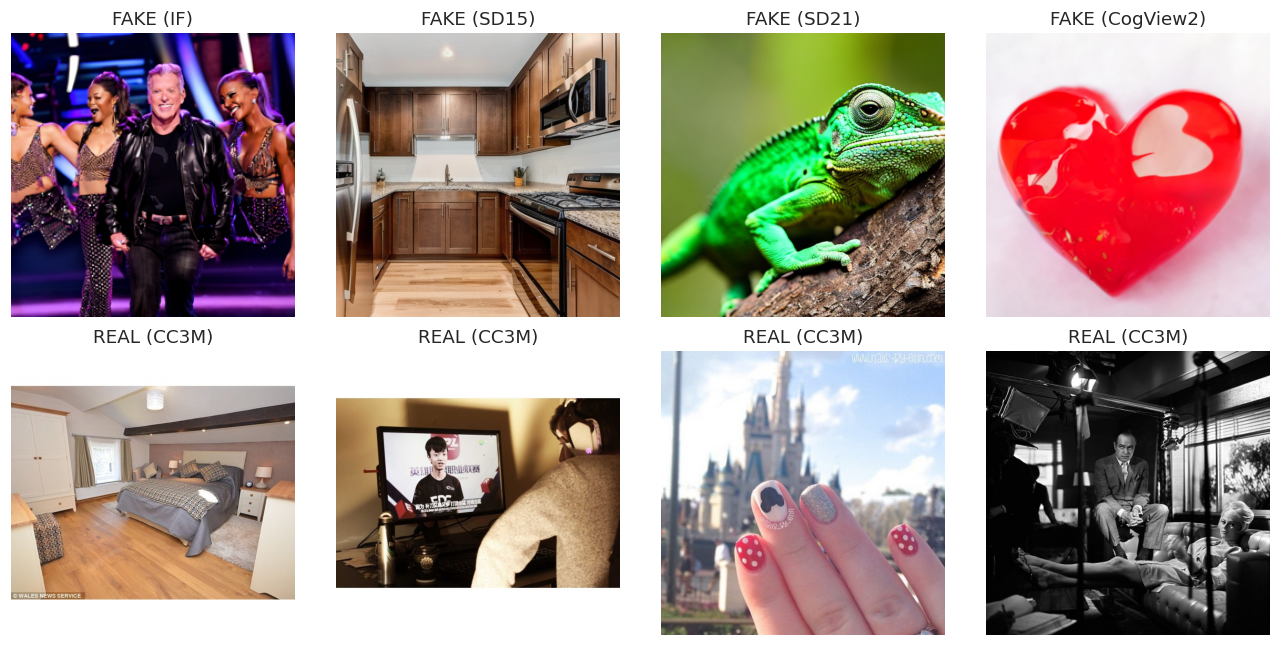

Streaming pipeline OK.


In [38]:
# Quick sanity check: pull a handful of samples from each stream and look at them before
# launching anything expensive. This also validates network access to both repos.
fake_preview = list(itertools.islice(stream_fake_images("val", limit_per_generator=1), 4))
real_preview = list(itertools.islice(stream_real_images("val", limit=4), 4))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (img, label, gen) in zip(axes[0], fake_preview):
    ax.imshow(img); ax.set_title(f"FAKE ({gen})"); ax.axis("off")
for ax, (img, label, gen) in zip(axes[1], real_preview):
    ax.imshow(img); ax.set_title(f"REAL ({gen})"); ax.axis("off")
plt.tight_layout()
plt.show()
print("Streaming pipeline OK.")


In [39]:
IMAGE_TRANSFORM = T.Compose([
    T.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats, matches the pretrained CNN
])


class RealFakeIterableDataset(torch.utils.data.IterableDataset):
    """Interleaves the fake and real streams 1:1 into a balanced binary-classification stream.

    `limit_per_class=None` means "use everything available" for this split -- note the two
    sources aren't the same total size (see Section 8's honest-imbalance note for `val`).
    """

    def __init__(self, split, limit_per_class=None, transform=IMAGE_TRANSFORM):
        super().__init__()
        self.split = split
        self.transform = transform
        n_generators = len(FAKE_SUBSETS[split])
        self.fake_limit = None if limit_per_class is None else max(1, limit_per_class // n_generators)
        self.real_limit = limit_per_class

    def __iter__(self):
        fake_stream = stream_fake_images(self.split, limit_per_generator=self.fake_limit)
        real_stream = stream_real_images(self.split, limit=self.real_limit)
        # zip_longest substitutes the WHOLE missing item with `fillvalue` (i.e. plain None,
        # not a (None, None, None) triple) once the shorter stream runs out -- so each side
        # must be None-checked *before* unpacking, not unpacked directly in the for-target.
        for fitem, ritem in itertools.zip_longest(fake_stream, real_stream, fillvalue=None):
            if fitem is not None:
                fimg, flabel, fgen = fitem
                yield self.transform(fimg), flabel, fgen
            if ritem is not None:
                rimg, rlabel, rgen = ritem
                yield self.transform(rimg), rlabel, rgen


## 4. Classical CNN encoder

This plays the same role DistilBERT plays in the text pipeline: a large frozen pretrained encoder that
turns raw input into a compact, semantically rich embedding, which a small trainable "bridge" then
compresses further before the quantum circuit.


In [40]:
def build_frozen_cnn_encoder(backbone=CONFIG["cnn_backbone"]):
    if backbone == "resnet18":
        net = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        net.fc = nn.Identity()  # output the 512-d pooled feature, not the 1000-way classifier
        embed_dim = 512
    else:
        raise ValueError(f"Unsupported backbone: {backbone}")

    net.eval()
    for p in net.parameters():
        p.requires_grad = False
    return net.to(DEVICE), embed_dim


CNN_ENCODER, CNN_EMBED_DIM = build_frozen_cnn_encoder()
assert CNN_EMBED_DIM == CONFIG["cnn_embed_dim"], "update CONFIG['cnn_embed_dim'] if you change the backbone"


@torch.no_grad()
def extract_cnn_embedding(images):
    """images: [B, 3, H, W] normalized tensor -> [B, cnn_embed_dim] frozen embedding."""
    return CNN_ENCODER(images.to(DEVICE))


## 5. Quantum-hybrid model — QPIE-style amplitude encoding + variational circuit

This mirrors the QHBERT text architecture exactly (frozen encoder → bridge → quantum circuit → head),
swapping:
- DistilBERT → the frozen CNN above.
- Angle embedding → **amplitude embedding**, i.e. QPIE. `Quatum-Image-Processing`'s own `encode_image()`
  (in `Quantum Image Encoding and QFT for grayscale images.ipynb`) does exactly this: L2-normalize the
  pixel vector, then `qc.initialize(normalized_array, qubits)` — that *is* amplitude encoding.
  `qml.AmplitudeEmbedding` is the batched, backprop-differentiable equivalent, which is what makes
  training on a full-scale stream tractable (the repo's own Qiskit circuits are built for single-image
  demonstration, not batched training).
- 6 qubits, because 2⁶=64 matches the repo's own 8×8-pixel-patch granularity (see `QHED.ipynb`'s `n = 6`)
  — the bridge below compresses the CNN embedding down to exactly 64 values, i.e. one QPIE-encodable
  "patch" that summarizes the whole image.
- The entangling + rotation ansatz (ring CNOTs + RY/RZ, 3 layers) is unchanged from the QHBERT text circuit.

**Why `diff_method="backprop"` on `default.qubit`, not a faster simulator:** the amplitude-embedding input
(`patch`) comes from the trainable bridge network, so gradients must flow back through the embedding into
the bridge's weights. `backprop` guarantees that. Faster alternatives like `lightning.qubit` +
`diff_method="adjoint"` are not reliably differentiable through an embedding template's *input* the same
way — using one there risks the bridge silently never receiving gradients. If you explore faster
simulators later, verify the bridge weights actually change during training before trusting results.


In [41]:
N_QUBITS = CONFIG["n_qubits"]
N_LAYERS = CONFIG["n_layers"]
PATCH_DIM = CONFIG["patch_dim"]
assert PATCH_DIM == 2 ** N_QUBITS

qdevice = qml.device("default.qubit", wires=N_QUBITS)
QUANTUM_DIFF_METHOD = "backprop"


@qml.qnode(qdevice, interface="torch", diff_method=QUANTUM_DIFF_METHOD)
def qpie_circuit(inputs, weights):
    """QPIE-style amplitude encoding of a 64-value patch, followed by the same ring-CNOT +
    RY/RZ variational ansatz used in this project's text (QHBERT) circuit.

    NOTE: the first argument must be named exactly `inputs` -- qml.qnn.TorchLayer requires
    this literal name to identify which argument receives the (non-trainable) input data,
    as opposed to `weights` (trainable). Naming it anything else raises:
    TypeError: QNode must include an argument with name inputs for inputting data.
    """
    qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), normalize=True)
    for layer in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
        for wire in range(N_QUBITS):
            qml.RY(weights[layer, wire, 0], wires=wire)
            qml.RZ(weights[layer, wire, 1], wires=wire)
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


QUANTUM_WEIGHT_SHAPES = {"weights": (N_LAYERS, N_QUBITS, 2)}


class QuantumImageClassifier(nn.Module):
    """Frozen CNN -> bridge (-> 64-d vector) -> QPIE amplitude embedding -> VQC -> head."""

    def __init__(self, cnn_embed_dim=CONFIG["cnn_embed_dim"], hidden=CONFIG["bridge_hidden"],
                 dropout=CONFIG["dropout"]):
        super().__init__()
        self.bridge = nn.Sequential(
            nn.Linear(cnn_embed_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, PATCH_DIM),
        )
        self.quantum = qml.qnn.TorchLayer(qpie_circuit, QUANTUM_WEIGHT_SHAPES)
        self.classifier = nn.Sequential(
            nn.Linear(N_QUBITS, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 2),
        )

    def forward(self, cnn_embedding):
        patch = self.bridge(cnn_embedding)
        q_out = self.quantum(patch)  # qpie_circuit L2-normalizes internally via AmplitudeEmbedding(normalize=True)
        return self.classifier(q_out)


## 6. Classical-only baseline (ablation)

Same frozen CNN embedding, but the bridge feeds directly into a classical head — no quantum layer. This
mirrors the "Remove Quantum → effect of the quantum layer" ablation already planned for the text pipeline
(`implementation_milestone.md` §10.3), so we can honestly report whether the quantum layer helps here too.


In [42]:
class FrozenCNNBaseline(nn.Module):
    def __init__(self, cnn_embed_dim=CONFIG["cnn_embed_dim"], hidden=CONFIG["bridge_hidden"],
                 dropout=CONFIG["dropout"]):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cnn_embed_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 2),
        )

    def forward(self, cnn_embedding):
        return self.net(cnn_embedding)


## 7. Training

Differential learning rates for classical vs. quantum parameters (same pattern as `qiskit.ipynb`).
Checkpoints save every `checkpoint_every_n_steps` steps *and* at the end of every epoch, to
`CONFIG["checkpoint_dir"]` — since Kaggle/Colab sessions are time-limited and a full "use all data" pass
will likely span more than one session.

**Resumability caveat (honest limitation):** streaming datasets don't support random-access seeking, so
resuming mid-epoch re-iterates (and re-downloads/decodes) the batches already completed in that epoch
before continuing — cheap on compute, not free on bandwidth/time. Progress from *fully completed* epochs
is never lost. Also see the `epochs` note in Section 2: every epoch re-streams the entire corpus, so
multi-epoch training multiplies total network transfer accordingly.


In [43]:
def checkpoint_path(model_name):
    return os.path.join(CONFIG["checkpoint_dir"], f"{model_name}.pt")


def save_checkpoint(model_name, model, optimizer, epoch, step_in_epoch):
    torch.save({
        "epoch": epoch,
        "step_in_epoch": step_in_epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, checkpoint_path(model_name))


def load_checkpoint(model_name, model, optimizer):
    path = checkpoint_path(model_name)
    if not os.path.exists(path):
        return 0, 0
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    print(f"Resumed {model_name} from epoch {ckpt['epoch']}, step {ckpt['step_in_epoch']}")
    return ckpt["epoch"], ckpt["step_in_epoch"]


In [44]:
def make_optimizer(model, quantum_param_names=("quantum",)):
    quantum_params, classical_params = [], []
    for name, p in model.named_parameters():
        (quantum_params if any(q in name for q in quantum_param_names) else classical_params).append(p)
    param_groups = [{"params": classical_params, "lr": CONFIG["lr_classical"]}]
    if quantum_params:
        param_groups.append({"params": quantum_params, "lr": CONFIG["lr_quantum"]})
    return torch.optim.Adam(param_groups)


def train_one_model(model_name, model, split="train"):
    model = model.to(DEVICE)
    optimizer = make_optimizer(model)
    criterion = nn.CrossEntropyLoss()
    start_epoch, resume_step = load_checkpoint(model_name, model, optimizer)

    history = {"loss": []}
    for epoch in range(start_epoch, CONFIG["epochs"]):
        dataset = RealFakeIterableDataset(split, limit_per_class=CONFIG["N_TRAIN_PER_CLASS"])
        # num_workers=0: IterableDataset needs manual per-worker sharding to parallelize safely
        # (otherwise each worker would restream the same data) -- single-process keeps this correct.
        loader = torch.utils.data.DataLoader(dataset, batch_size=CONFIG["batch_size"])

        model.train()
        step = 0
        pbar = tqdm(loader, desc=f"{model_name} epoch {epoch}")
        for images, labels, _gens in pbar:
            step += 1
            if epoch == start_epoch and step <= resume_step:
                continue  # fast-forward past batches already trained this epoch (see markdown above)

            labels = labels.to(DEVICE)
            embedding = extract_cnn_embedding(images)
            logits = model(embedding)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history["loss"].append(loss.item())
            pbar.set_postfix(loss=loss.item())

            if step % CONFIG["checkpoint_every_n_steps"] == 0:
                save_checkpoint(model_name, model, optimizer, epoch, step)

        save_checkpoint(model_name, model, optimizer, epoch + 1, 0)  # epoch fully done -> reset step counter
        resume_step = 0

    return model, history


In [45]:
quantum_model, quantum_history = train_one_model("quantum_hybrid", QuantumImageClassifier())


Resumed quantum_hybrid from epoch 0, step 1200


quantum_hybrid epoch 0: 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

quantum_hybrid epoch 1: 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

quantum_hybrid epoch 2: 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

In [46]:
baseline_model, baseline_history = train_one_model("classical_baseline", FrozenCNNBaseline())


classical_baseline epoch 0: 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

classical_baseline epoch 1: 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

classical_baseline epoch 2: 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

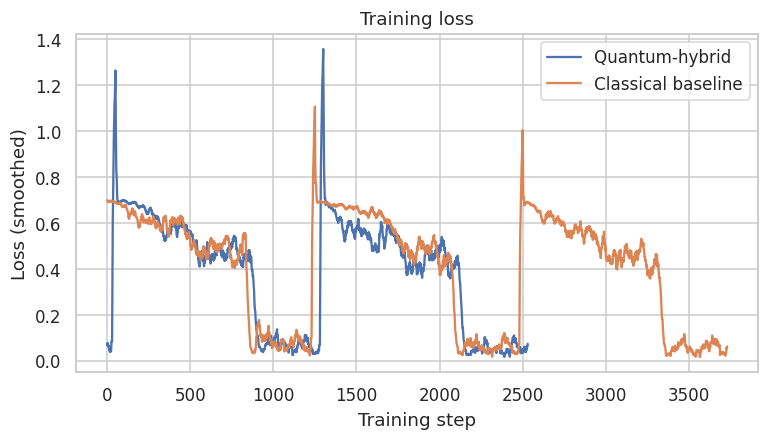

In [47]:
def smooth(values, window=20):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")


plt.figure(figsize=(8, 4))
plt.plot(smooth(quantum_history["loss"]), label="Quantum-hybrid")
plt.plot(smooth(baseline_history["loss"]), label="Classical baseline")
plt.xlabel("Training step"); plt.ylabel("Loss (smoothed)")
plt.title("Training loss"); plt.legend()
plt.show()


## 8. Evaluation

Overall metrics plus a **per-generator breakdown** on the validation split (IF / SD v1.5 / SD v2.1 /
CogView2 / StyleGAN3 / Midjourney v5 vs. real CC3M) — mirroring this project's existing multi-benchmark
culture. Note the validation classes are naturally imbalanced (~227K fake across 6 generators vs. ~13.4K
real, since that's `pixparse/cc3m-wds`'s entire official validation split) — reported metrics below include
per-class support so this is transparent, not hidden.


In [48]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix,
)


@torch.no_grad()
def evaluate(model, split="val", limit_per_class=None):
    model.eval()
    dataset = RealFakeIterableDataset(split, limit_per_class=limit_per_class)
    loader = torch.utils.data.DataLoader(dataset, batch_size=CONFIG["batch_size"])

    all_labels, all_preds, all_probs, all_gens = [], [], [], []
    for images, labels, gens in tqdm(loader, desc=f"evaluating ({split})"):
        embedding = extract_cnn_embedding(images)
        logits = model(embedding)
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = logits.argmax(dim=-1)

        all_labels.extend(labels.tolist())
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
        all_gens.extend(gens)

    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "auc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else float("nan"),
        "n": len(all_labels),
    }

    per_generator = {}
    for gen in sorted(set(all_gens)):
        idx = [i for i, g in enumerate(all_gens) if g == gen]
        gen_labels = [all_labels[i] for i in idx]
        gen_preds = [all_preds[i] for i in idx]
        # all samples in one generator share the same true label, so "accuracy" here IS the
        # detection rate for that generator (or the true-negative rate, for CC3M).
        per_generator[gen] = {"n": len(idx), "accuracy": accuracy_score(gen_labels, gen_preds)}

    cm = confusion_matrix(all_labels, all_preds)
    return metrics, per_generator, cm


evaluating (val): 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

evaluating (val): 0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

Quantum-hybrid: {
  "accuracy": 0.593368673734747,
  "f1": 0.3182694726251362,
  "precision": 0.9829104091144485,
  "recall": 0.18987595038015206,
  "auc": 0.8294653661464586,
  "n": 19996
}
Classical baseline: {
  "accuracy": 0.6027205441088218,
  "f1": 0.3477832512315271,
  "precision": 0.9697802197802198,
  "recall": 0.2118847539015606,
  "auc": 0.8218198629451781,
  "n": 19996
}


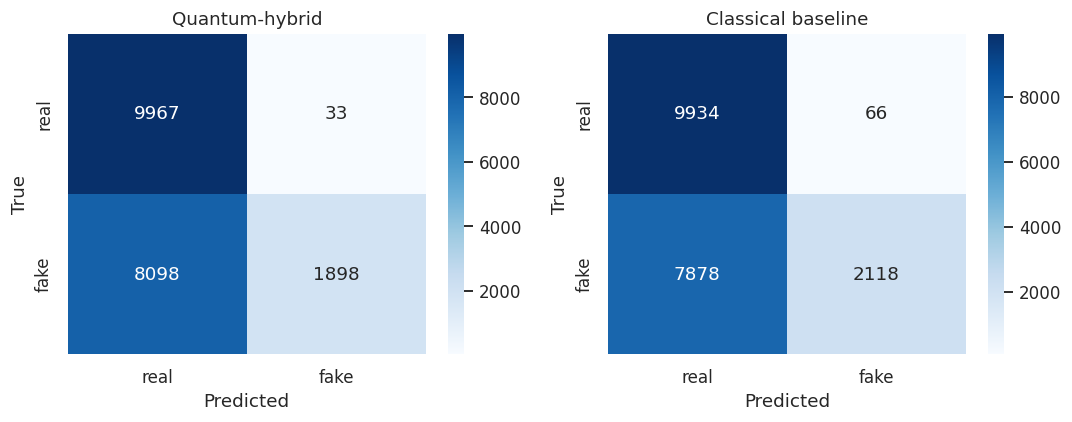

,Quantum-hybrid accuracy,n,Classical baseline accuracy
CC3M,0.996700,10000,0.993400
CogView2,0.020408,1666,0.027011
IF,0.025210,1666,0.052821
Midjourneyv5,0.027611,1666,0.073229
SD15,0.045618,1666,0.079232
SD21,0.029412,1666,0.042617
StyleGAN3,0.990996,1666,0.996399


In [49]:
quantum_metrics, quantum_per_gen, quantum_cm = evaluate(
    quantum_model, split="val", limit_per_class=CONFIG["N_VAL_PER_CLASS"]
)
baseline_metrics, baseline_per_gen, baseline_cm = evaluate(
    baseline_model, split="val", limit_per_class=CONFIG["N_VAL_PER_CLASS"]
)

print("Quantum-hybrid:", json.dumps(quantum_metrics, indent=2))
print("Classical baseline:", json.dumps(baseline_metrics, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes, [quantum_cm, baseline_cm], ["Quantum-hybrid", "Classical baseline"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"],
                yticklabels=["real", "fake"], ax=ax)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

per_gen_df = pd.DataFrame({
    "Quantum-hybrid accuracy": {g: v["accuracy"] for g, v in quantum_per_gen.items()},
    "n": {g: v["n"] for g, v in quantum_per_gen.items()},
    "Classical baseline accuracy": {g: v["accuracy"] for g, v in baseline_per_gen.items()},
})
per_gen_df


## 9. Quantum-hybrid vs. classical baseline

Same comparison-table convention as `implementation_milestone.md` §10.2.


In [50]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


comparison = pd.DataFrame([
    {"Model": "Classical baseline", **baseline_metrics, "Trainable params": count_trainable_params(baseline_model)},
    {"Model": "Quantum-hybrid (QPIE+VQC)", **quantum_metrics, "Trainable params": count_trainable_params(quantum_model)},
]).set_index("Model")
comparison


,accuracy,f1,precision,recall,auc,n,Trainable params
Model,,,,,,,
Classical baseline,0.602721,0.347783,0.96978,0.211885,0.821820,19996,68018
Quantum-hybrid (QPIE+VQC),0.593369,0.318269,0.98291,0.189876,0.829465,19996,74358


## 10. QHED demo — running the repo's actual edge-detection code

`Quatum-Image-Processing/QHED.ipynb` implements Quantum Hadamard Edge Detection: normalize an 8×8
(64-pixel) patch into amplitudes (QPIE again, at the pixel level this time), prepare it on 6 data qubits +
1 ancilla, apply a Hadamard–shift–Hadamard sandwich on the ancilla, and read off where the resulting
amplitudes are non-zero — that marks an edge. A full image is edge-detected by tiling it into 8×8 patches
and running one small circuit per patch.

We run this **exact algorithm**, ported to run today (its original code calls `qiskit.execute` /
`qiskit.providers.aer.QasmSimulator`, both removed in current Qiskit releases — `Statevector(qc)` is the
direct modern equivalent for the same *ideal, noiseless* simulation the original code was doing). This
section is a small, illustrative demo only (a handful of sample images) — at 32×32 there are already 16
circuit executions per image; a full 256×256 image would need 1,024, so this genuinely doesn't scale to the
millions of images used above, which is exactly why the training pipeline in Sections 5-9 uses the batched,
backprop-differentiable amplitude-embedding approach instead.


In [51]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

QHED_N = 6                  # data qubits per 8x8=64-pixel patch (same as the repo's QHED.ipynb)
QHED_TOTAL_N = QHED_N + 1   # +1 Hadamard ancilla
QHED_PATCH = int(math.sqrt(2 ** QHED_N))  # 8
_QHED_SHIFT = np.roll(np.identity(2 ** QHED_TOTAL_N), 1, axis=1)  # the repo's "D2n_1" decrement operator


def _qhed_normalise(patch):
    amp = patch.reshape(-1, 1).astype(float)
    norm = np.linalg.norm(amp)
    if norm == 0:
        amp[0] = 1
        norm = np.linalg.norm(amp)
    return (amp / norm).flatten()


def qhed_edge_detect_patch(patch):
    """Faithful port of Quatum-Image-Processing/QHED.ipynb's edge_detection()+get_edge_scan(),
    modernized to Statevector(qc) since qiskit.execute/providers.aer.QasmSimulator no longer exist."""
    arr_h = _qhed_normalise(patch)
    arr_v = _qhed_normalise(patch.T)

    def _run(arr):
        qc = QuantumCircuit(QHED_TOTAL_N)
        qc.initialize(arr, range(1, QHED_TOTAL_N))
        qc.h(0)
        qc.unitary(_QHED_SHIFT, range(QHED_TOTAL_N))
        qc.h(0)
        return Statevector(qc).data

    sv_h, sv_v = _run(arr_h), _run(arr_v)
    threshold = lambda amp: amp > 1e-15 or amp < -1e-15
    edge_h = np.array([1 if threshold(sv_h[2 * i + 1].real) else 0
                        for i in range(2 ** QHED_N)]).reshape(QHED_PATCH, QHED_PATCH)
    edge_v = np.array([1 if threshold(sv_v[2 * i + 1].real) else 0
                        for i in range(2 ** QHED_N)]).reshape(QHED_PATCH, QHED_PATCH).T
    return edge_h | edge_v


def qhed_edge_detect_image(gray_img):
    """Tiles a (H, W) grayscale array into 8x8 patches, runs qhed_edge_detect_patch on each, and
    stitches the results back together (same split_image/combine_images pattern as the repo)."""
    h, w = gray_img.shape
    h -= h % QHED_PATCH
    w -= w % QHED_PATCH
    gray_img = gray_img[:h, :w]
    rows = []
    for r in range(0, h, QHED_PATCH):
        row_tiles = [qhed_edge_detect_patch(gray_img[r:r + QHED_PATCH, c:c + QHED_PATCH])
                     for c in range(0, w, QHED_PATCH)]
        rows.append(np.hstack(row_tiles))
    return np.vstack(rows)


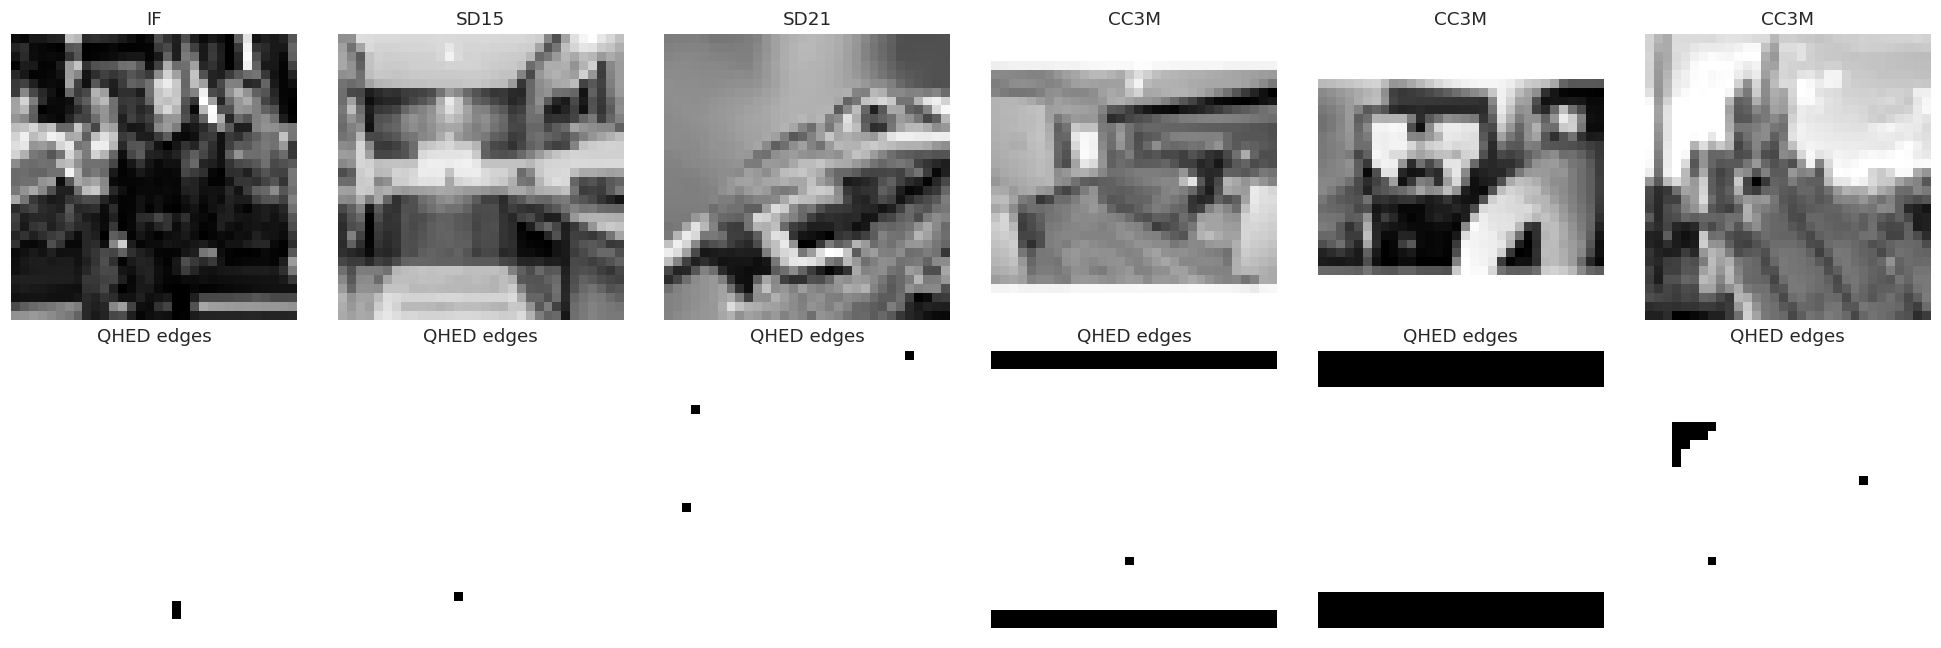

In [52]:
DEMO_SIZE = 32  # keep tiny: 32x32 -> 16 patches/image, so this cell finishes in well under a minute

demo_samples = fake_preview[:3] + real_preview[:3]  # reuse the smoke-test images from Section 3

fig, axes = plt.subplots(2, len(demo_samples), figsize=(3 * len(demo_samples), 6))
for col, (img, label, gen) in enumerate(demo_samples):
    gray = np.array(img.convert("L").resize((DEMO_SIZE, DEMO_SIZE)))
    edges = qhed_edge_detect_image(gray)

    axes[0, col].imshow(gray, cmap="gray"); axes[0, col].set_title(gen); axes[0, col].axis("off")
    axes[1, col].imshow(edges, cmap="gray"); axes[1, col].set_title("QHED edges"); axes[1, col].axis("off")
plt.tight_layout(); plt.show()


## 11. Honest limitations

- **This detects "AI-generated image vs. real photograph," not "this news article is fake."** It's the
  image-forensics signal a multimodal fake-news system would use, alongside the text signal this project's
  QHBERT pipeline already provides — it doesn't read headlines, article body, or source metadata. Fusing
  the two (e.g. concatenating this model's quantum-circuit output with QHBERT's) is the natural next step
  toward genuine multimodal detection, which the project's own literature review
  (`qhbert_papers_detailed_reference.md`, papers #8 QEMF and #10 QCNN-MFND) identifies as valuable but
  harder to do well.
- **`AmplitudeEmbedding` is simulated, not real quantum hardware** — same as the rest of this project so
  far (`qiskit.ipynb`/`implementation_milestone.md` only mention real IBM-hardware validation as optional
  future work). It also decomposes into a fairly deep gate sequence for 6 qubits; if you do try real
  hardware later, expect it to be considerably noisier than the angle-embedding circuit used for text.
- **The fake and real validation sets are not the same size** (~227K fake across 6 generators vs. ~13.4K
  real, since that's the entirety of `pixparse/cc3m-wds`'s official validation split) — Section 8 reports
  per-class support alongside every metric so this is visible rather than hidden.
- **Streaming, not cached**: every epoch re-streams from HuggingFace. That's what makes "use all data"
  possible without ~1TB of local storage, but it also means total wall-clock time is bandwidth-bound, and a
  flaky connection mid-epoch will raise rather than silently skip data — rerun the training cell (it
  resumes from the last checkpoint) if that happens.
- **QHED (Section 10) is illustrative only**, not part of the trained model — it's too slow to run at the
  millions-of-images scale used for training (see Section 10's markdown for the concrete numbers).


In [53]:
# === SAVE TRAINED MODELS ===

def save_final_model(model, model_name, save_dir="./final_models"):
    """Save trained model weights (not just checkpoint) for inference later."""
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f"{model_name}_final.pt")
    torch.save(model.state_dict(), path)
    print(f"Saved {model_name} to {path}")
    return path


def load_final_model(model_class, model_name, save_dir="./final_models"):
    """Restore trained model from saved weights."""
    path = os.path.join(save_dir, f"{model_name}_final.pt")
    model = model_class()
    model.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=True))
    model.to(DEVICE)
    model.eval()
    return model


@torch.no_grad()
def predict(model, image_tensor):
    """Single image prediction: image_tensor shape [3, 224, 224] (normalized)."""
    model.eval()
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)  # add batch dim
    embedding = extract_cnn_embedding(image_tensor)
    logits = model(embedding)
    prob_fake = torch.softmax(logits, dim=-1)[0, 1].item()
    return {"prob_fake": prob_fake, "prob_real": 1.0 - prob_fake}


# After training completes, save both models:
quantum_path = save_final_model(quantum_model, "quantum_hybrid")
baseline_path = save_final_model(baseline_model, "classical_baseline")

# Later, to reload and predict on a new image:
# 1. Load image (PIL or tensor)
# img = Image.open("path/to/image.jpg").convert("RGB")
# img_tensor = IMAGE_TRANSFORM(img)  # normalized [3, 224, 224]
#
# 2. Load model
# loaded_model = load_final_model(QuantumImageClassifier, "quantum_hybrid")
#
# 3. Predict
# pred = predict(loaded_model, img_tensor)
# print(f"Real: {pred['prob_real']:.2%}, Fake: {pred['prob_fake']:.2%}")


Saved quantum_hybrid to ./final_models/quantum_hybrid_final.pt
Saved classical_baseline to ./final_models/classical_baseline_final.pt


In [54]:
# Quick sanity check
loaded = torch.load("./final_models/quantum_hybrid_final.pt", map_location=DEVICE, weights_only=True)
print(f"Loaded {len(loaded)} parameter tensors")
print(f"Model size: {sum(p.numel() for p in loaded.values())} params")

# Restore to model
model = QuantumImageClassifier()
model.load_state_dict(loaded)
model.to(DEVICE)
print("✓ Model loaded successfully")


Loaded 11 parameter tensors
Model size: 74358 params
✓ Model loaded successfully
